In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [66]:
iris = load_iris()
X = iris.data

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
df = pd.DataFrame(X_scaled, columns = iris.feature_names)

In [69]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [70]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None


In [71]:
df.duplicated().sum()

np.int64(1)

In [72]:
df[df.duplicated(keep=False)]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
101,-0.052506,-0.82257,0.762758,0.922303
142,-0.052506,-0.82257,0.762758,0.922303


In [73]:
df = df.drop_duplicates()

In [74]:
y = iris.target

In [75]:
df = df.rename(columns={
    'sepal length (cm)': 'sl',
    'sepal width (cm)': 'sw',
    'petal length (cm)':'pl',
    'petal width (cm)':'pw'
})    

In [79]:
print(df.shape)
print(len(y))
y = pd.Series(y)
y = y.loc[df.index]

(149, 4)
149
149


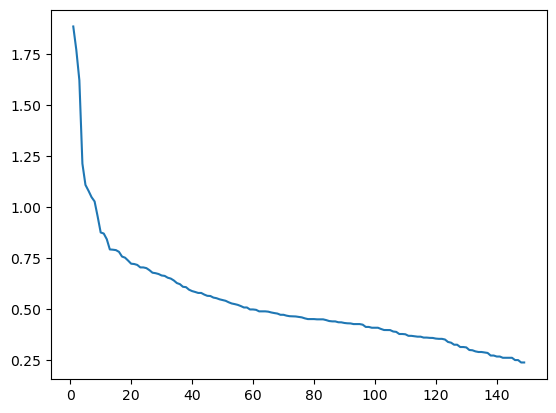

In [126]:
k = 5 
nbr = NearestNeighbors(n_neighbors = k).fit(df)
distances, indices = nbr.kneighbors(df)
distances_desc = sorted(distances[:,k-1], reverse = True)
plt.plot(list(range(1,len(distances_desc)+1)),distances_desc)

In [149]:
clustering = DBSCAN(eps=0.75,min_samples=5).fit(df)
labels = clustering.labels_

In [150]:
labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

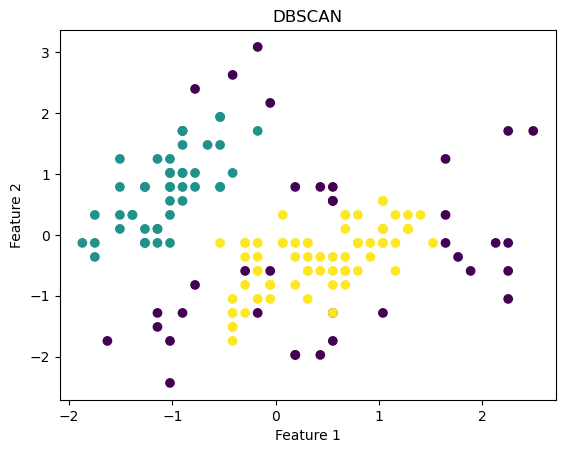

In [140]:
plt.title("DBSCAN")
plt.scatter(df.iloc[:,0], df.iloc[:,1], c = labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [151]:
mask = labels !=-1
sc = metrics.silhouette_score(df[mask],labels[mask])

In [152]:
print(sc)

0.6010332318830887


In [153]:
rand = metrics.adjusted_rand_score(y,labels)

In [154]:
rand

0.5430543083354109